# Study 05 · Grey-box expectation and monitoring of the station 02 inclination

A reading arrives every twenty minutes: inclination, air temperature,
relative humidity, and, since February 2025, wall temperature and solar
radiation. This study answers the question Study 04 posed and did not fully
answer:

> **Given the environment measured at this instant, is this inclination the
> one the wall was expected to show — and if not, which kind of departure is
> it?**

This study inherits Study 01's compensated, once-anchored, spike-cleaned
inclination record; Study 02's characterisation of the station and ERA5
proxies; Study 03's measured delays, gains and directions of the couplings;
and Study 04's own honestly-stated weak points, which are the reason this
study exists. The manufacturer's thermal compensation is taken as given
throughout — no raw-channel fit is made, and every gain learned here is a
post-compensation wall response, labelled as such. Forecasting stays out of
scope: Study 04 already answered it, finding that skill comes from the
response's own memory and that the environment adds nothing distinguishable
from zero beyond six hours.

The analysis proceeds in the following movements, one phase of the design's
§8 at a time, each opened only after its predecessor's checkpoint is shown
to the user and approved:

1. **Data and regressor sets (Phase 1).** Loaders, clock check, upsampling
   onto the study's grid, and the filling of short regressor gaps, across
   the three regressor sets.
2. **Harmonic diagnostics (Phase 1b).** A spectral scan of the target and of
   the post-regressor residual, the daily cycle's amplitude and phase
   measured over eight years, and the rank of the daily-by-annual surface —
   fixing the seasonal Fourier orders and the conditional-seasonality
   weight curve before any model is fitted.
3. **Model A attribution on three sets (Phase 2).** Component shares,
   learned gains beside Study 03's, trend and seasonal parameters, the
   conditional-seasonality test, fold stability, and residual diagnostics.
4. **Current-era ladder (Phase 2b).** Wall temperature and the on-structure
   pyranometer tested rung by rung on the current era, to say what each
   buys over the on-structure set alone.
5. **Expectation and interval (Phase 3).** A rolling refit with rolling
   conformal calibration, and interval metrics reported by days since
   refit.
6. **Model B impulse response (Phase 4).** A learned lagged-regressor
   response on air temperature and station radiation, confronted with
   Study 03's imposed delay-and-time-constant operator.
7. **The monitor (Phase 5).** Reference statistics, prewhitening, the three
   charts, alarm attribution, and detectability with injections re-sized to
   the wall's measured daily response.
8. **Outage bridges (Phase 6).** The expected level at resumption from
   proxies that kept recording, against the level observed, per outage and
   per proxy set.

Phase 0 (smoke tests and housekeeping) precedes these movements outside the
notebook, and Phase 7 (the report) follows them; see
docs/superpowers/specs/2026-09-05-study05-greybox-monitoring-design.md §8
for the full phase and checkpoint sequence.

## Imports and parameters

All library operations live in `shmlib`. This notebook owns the data
pointers and the choices that make this one study: the regressor sets, the
harmonic-diagnostic settings, the two models, the monitor, and the outage
bridges.

In [1]:
import logging
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from neuralprophet import set_random_seed

sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../..'))

from shmlib import (coupling, figures, monitoring, prediction, proxies,
                    quality, site, solar, tables, viz)

warnings.filterwarnings('ignore')
logging.getLogger('pytorch_lightning').setLevel(logging.ERROR)
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
viz.apply_report_style()

/Users/eugenio/anaconda3/envs/neuralprophet_env/lib/python3.10/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


Importing plotly failed. Interactive plots will not work.


Importing plotly failed. Interactive plots will not work.


## Parameters · Paths and grid

Data pointers and the study's native grid. Every path below is declared
here and passed into `shmlib` loaders as an argument; none is hard-coded in
a library function.

### Parameter Tuning Guidance

**`ARCHIVE_CSV`** — path to Study 1's verdict-aware archive product, the
on-structure sensor package at its native cadence; default
`'../../data/interim/archive/gubbio_archive_20min.csv'`. Every study since
Study 1 reads this file rather than a raw `.adc` file.

**`STATION_CSV`** — path to the town ground-station export; default
`'../../data/raw/proxies/meteosystem_gubbio.csv'`. Loaded through
`shmlib.proxies.load_ground_station`.

**`ERA5_CSV`** — path to the Oikolab ERA5 reanalysis export; default
`'../../data/raw/proxies/oikolab_weather.csv'`. Loaded through
`shmlib.proxies.load_era5`.

**`OUTPUT_DIR`** — where every `GM_` table and figure is written; default
`Path('outputs')`, gitignored and regenerated by running the notebook.

**`NATIVE_FREQ`** — the study's working grid; default `'20min'`, the
archive's native spacing and the rate at which a deployed system receives a
reading. Model A and the monitor run on this grid; Model B may fall back to
an hourly grid under `MODEL_B_FALLBACK_FREQ` if Phase 0 finds that
NeuralProphet 0.8.0 cannot carry lagged regressors at `n_lags=0`.

**`TARGET_COLUMN`** — the response; default `'inc_comp_cleaned'`, Study 1's
compensated, once-anchored, spike-cleaned inclination product. No raw or
intermediate channel is used (D1, §2.4).

**`SPIKE_COLUMN`** — Study 1's interpolation flag; default `'inc_spike'`.
Read alongside the target so an interpolated value can be told from a
measured one wherever that distinction matters downstream.

**`WINDOW_START`** — the first instant of the study window; default
`'2018-07-26'`, the archive's first day (D1). Unlike Study 04, this study
uses the whole record rather than one post-outage segment.

**`WINDOW_END`** — the last instant of the study window; default `None`,
meaning the archive's own end. Set explicitly only to freeze a result
against a growing archive.

In [2]:
ARCHIVE_CSV = '../../data/interim/archive/gubbio_archive_20min.csv'
STATION_CSV = '../../data/raw/proxies/meteosystem_gubbio.csv'
ERA5_CSV = '../../data/raw/proxies/oikolab_weather.csv'
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

NATIVE_FREQ = '20min'
TARGET_COLUMN = 'inc_comp_cleaned'
SPIKE_COLUMN = 'inc_spike'

WINDOW_START = '2018-07-26'
WINDOW_END = None            # None: the archive's own end

## Parameters · Regressor sets

One model specification runs through three regressor sets — on-structure,
station and ERA5 — mapping each of three roles (air temperature, relative
humidity, solar radiation) to its source column (D2, D3). Radiation is
global horizontal in every set, delayed by `RADIATION_DELAY_H` and passed
through `shmlib.coupling.thermal_operator`; air temperature and humidity
enter instantaneous.

### Parameter Tuning Guidance

**`STR_MAP_CURRENT`** — the current-era (post-2025-02-21) block-to-quantity
map, copied verbatim from Study 04's own parameter cell
(`04_neuralprophet_inclination_prediction/neuralprophet_inclination_prediction_study.py`
lines 253-259); default maps `tair`, `sr`, `twall`, `rh` and `batt` to the
archive's current-era `_ok`/`_filtered` columns. Passed to
`shmlib.proxies.load_sensor_forcings` so this study's on-structure load is
the same choice Study 04 already validated, rather than a second,
independently drifting definition of "the current era's channels".

**`STR_MAP_LEGACY`** — the legacy-era block-to-quantity map, copied
verbatim from the same lines (260-263) of Study 04; default maps `tair`,
`rh` and `batt` to the legacy block's station-prefixed `_ok` columns
(`site.TARGET_STATION` resolves the block). No `sr` or `twall` entry: the
legacy package carries neither channel, and `load_sensor_forcings` leaves
an unmapped role out of its output rather than inventing one.

**`REGRESSOR_SETS`** — dict of set name to a role-to-column mapping. Three
keys, `'str'`, `'gs'`, `'era5'`. The `'str'` set reads `tair_str` and
`rh_str`, `load_sensor_forcings`' own column names for the on-structure
quantities joined across the two instrument eras by `join_eras`, and
borrows the station's own radiation column `sr_gs` because the wall's own
pyranometer does not exist before 2025-02-21 and Study 01 condemned 161 of
its days after that (D2); every table that reports the `'str'` set states
this borrowing. The `'gs'` and `'era5'` sets read `shmlib.proxies`' own
suffixed columns (`{quantity}_gs`, `{quantity}_era5`) unchanged. Accepted
values: any mapping of `{'tair', 'rh', 'sr'}` to a column present in the
joined frame; default as given in D2's table. Changing a mapping changes
which columns Phase 1's loaders are asked to join, and therefore every
downstream gain and coverage number for that set.

**`RADIATION_DELAY_H`** — the delay applied to every radiation source
before it enters Model A, in hours; default `1`, the diurnal-band optimum
measured in Study 03 for all three radiation sources (D3). Applied through
`shmlib.coupling.thermal_operator`, never inside the model itself.

**`REGRESSOR_FILL_MAX_GAP`** — the longest regressor gap filled by linear
interpolation before the row is dropped from a set's fit; default `'2h'`
(D13). A regressor is a measured, smooth driver rather than the thing being
judged, so short dust is filled and flagged; a longer gap leaves the row
out of the fit for that set only. Raising it trades coverage for the risk
of interpolating across a real excursion.

**`ERA5_SR_IS_ACCUMULATION`** — whether the ERA5 radiation column is an
accumulation over the preceding hour rather than an instantaneous reading;
default `True` (D13). When `True`, the loader centres the value on the
half-hour before interpolating onto the study's grid.

In [3]:
STR_MAP_CURRENT = {
    'tair': 'tair',
    'sr': 'n_sr_ok',
    'twall': 'n_twall_filtered',
    'rh': 'n_rh_ok',
    'batt': 'n_batt_ok',
}
STR_MAP_LEGACY = {
    'tair': 'tair',
    'rh': f'{site.TARGET_STATION}_rh_ok',
    'batt': f'{site.TARGET_STATION}_batt_ok',
}
REGRESSOR_SETS = {
    'str': {'tair': 'tair_str', 'rh': 'rh_str', 'sr': 'sr_gs'},   # sr borrowed from the station (D2)
    'gs': {'tair': 'tair_gs', 'rh': 'rh_gs', 'sr': 'sr_gs'},
    'era5': {'tair': 'tair_era5', 'rh': 'rh_era5', 'sr': 'sr_era5'},
}
RADIATION_DELAY_H = 1
REGRESSOR_FILL_MAX_GAP = '2h'
ERA5_SR_IS_ACCUMULATION = True

## Parameters · Harmonic diagnostics (Phase 1b)

Before any model is fitted, the seasonal Fourier orders and the
conditional daily term's weight curve are fixed by measurement rather than
by guess (D6). Two series are scanned: the target itself, and the residual
of a plain least-squares regression of the target on the on-structure
regressors — what the seasonal terms will actually have to explain.

### Parameter Tuning Guidance

**`PERIOD_SCAN_BANDS`** — the period ranges the Lomb–Scargle scan
certifies, each scanned and ranked on its own; default
`{'short': (0.4, 3.0), 'long': (30.0, 900.0)}`. A single ranking spanning
both bands lets the long-period continuum bury the short one: the
sub-daily peaks carry a small share of the record's variance and are
outranked by the annual-ish and multi-hundred-day peaks before a top-`k`
cut ever gets to them, even when the sub-daily peaks are genuinely
present. Scanning the bands separately gives each its own ranking. The
`'short'` band brackets the daily and twelve-hour cycles; the `'long'`
band brackets the annual and semi-annual ones. The grid edge `900.0`
days is about a third of the eight-year record and is not itself a
certified period — it exists so a slower structure is not aliased into
the annual band.

**`DAILY_HARMONIC_MIN_SLOTS`** — minimum number of the day's 72 slots
required before a day's 24-hour harmonic is fitted; default `60`,
matching Study 04's rule for a day informative enough to trust. A gappier
day contributes no amplitude or phase estimate rather than a noisy one.

**`ANNUAL_MODULATION_HARMONICS`** — Fourier orders tried when fitting the
measured daily amplitude and phase against day of year; default `(1, 2)`.
The order actually used is chosen on held-out years and reported in
`GM_04`, never raised beyond what the scan supports.

**`SURFACE_DOY_BINS`** — number of day-of-year bins the diurnal-band
surface is binned into before its singular value decomposition; default
`52`, one bin per week. Coarser binning trades resolution of the annual
modulation for a less noisy surface.

**`PERIOD_SCAN_N`** — number of log-spaced candidate periods scanned
*per band* of `PERIOD_SCAN_BANDS`; default `40000`, which at one day
gives a spacing of about `0.0002` days, inside the eight-year record's
resolution, so the daily and twelve-hour peaks are sampled rather than
stepped over within the short band. Fewer points make each band's scan
faster and coarser.

**`ANNUAL_MODULATION_MIN_GAIN`** — the fraction by which a higher Fourier
order must lower the leave-one-year-out error before it is preferred over
a lower one; default `0.01`. A value of zero returns to the bare
lowest-error choice, which on a nearly sinusoidal modulation is decided
by noise.

In [4]:
PERIOD_SCAN_BANDS = {'short': (0.4, 3.0), 'long': (30.0, 900.0)}
DAILY_HARMONIC_MIN_SLOTS = 60
ANNUAL_MODULATION_HARMONICS = (1, 2)
SURFACE_DOY_BINS = 52
PERIOD_SCAN_N = 40000
ANNUAL_MODULATION_MIN_GAIN = 0.01

## Parameters · Model A

The additive grey-box specification without autoregression: a trend, an
annual term, a conditionally-weighted daily term, and the three regressor
roles of one set, fitted with NeuralProphet's own quantile regression
(D7).

### Parameter Tuning Guidance

**`N_CHANGEPOINTS`** — trend changepoints, placed on covered time through
`prediction.covered_changepoints`; default `12`, Study 04's value, swept
in Phase 2 against the whole-record window rather than assumed unchanged.

**`CHANGEPOINTS_RANGE`** — fraction of the training range eligible to
carry a changepoint; default `0.95`.

**`TREND_REG`** — regularization on the trend's rate changes; default
`None`, swept in Phase 2 (D7, NeuralProphet tutorial 02 and the sub-daily
guide).

**`YEARLY_ORDER`** — Fourier order of the annual term; default `1`, fixed
from `GM_04` (D6): the regression residual certifies the annual cycle in its
long band and no semi-annual one, so a second harmonic would have nothing to
fit. Never raised beyond what the scan supports.

**`DAILY_ORDER`** — Fourier order of the daily term(s); default `2`, fixed
from `GM_04` (D6): both series certify the 12-hour companion of the daily
cycle in the short band, the signature of a response that heats faster than
it cools.

**`WEEKLY_SEASONALITY`** — whether a weekly term is fitted; default
`False`. Nature does not follow the week (D7).

**`MODEL_A_LAGS`** — autoregressive lags; must stay `0`. Any positive
value transfers the diurnal structure into the autoregressive term and
makes the decomposition unreadable as physics (kept unchanged from Study
04, §2.4).

**`QUANTILES`** — the interval's quantiles; default `(0.05, 0.95)`, a
nominal 90 % interval. Must match `CONFORMAL_ALPHA` in the group below.

**`LEARNING_RATE`, `EPOCHS`** — NeuralProphet's own training parameters;
default `0.01` and `30`, Study 04's values.

**`SEED`** — passed to `neuralprophet.set_random_seed` before every fit;
default `0`, for a reproducible changepoint placement and initialization.

**`MIN_TRAIN`** — shortest history a window must hold before it is
allowed to speak; default `'730d'`, two full annual cycles — the minimum
the model carrying an annual term can identify (D7).

**`REFIT_EVERY`** — how often the rolling expectation refits; default
`'30d'` (D5). Over thirty days the trend's extrapolation error stays a
fraction of a millidegree at the measured drift rates, and the residual it
leaves is stationary enough for the monitor to chart.

**`CONDITIONAL_DAILY`** — whether the daily term is fitted as two
smoothly weighted conditional seasonalities (summer and winter shapes)
rather than one plain daily term; default `True` (D7). Kept only if it
improves held-out MAE or clears `CONDITIONAL_KEEP_MIN_SHARE`; the
comparison is reported either way.

**`WEIGHT_CURVE`** — the annual weight curve `w(doy)` blending the two
conditional daily shapes; default the order-two annual Fourier fit of the
regression residual's daily amplitude measured in `GM_04` (D6, D7): the
coefficients are the constant, the first cosine and sine and the second
cosine and sine over a period of 365.25 days, fitted on 1,752 days, and
`prediction.seasonal_weights` normalises the curve to 0..1, where it peaks
on day 206. The documented fallback, used only if the measured curve is no
better on held-out folds, is the mid-July cosine
`½(1 − cos(2π(doy − 15)/365))`, selected by setting this to `None`.

**`CONDITIONAL_KEEP_MIN_SHARE`** — minimum variance share the conditional
daily term must carry to be kept over the plain daily term when held-out
MAE does not already decide it; default `0.01` (D7).

In [5]:
N_CHANGEPOINTS = 12
CHANGEPOINTS_RANGE = 0.95
TREND_REG = None              # swept in Phase 2
YEARLY_ORDER = 1              # GM_04: annual peak certified on the residual, no semi-annual one
DAILY_ORDER = 2               # GM_04: the 12-hour companion of the daily cycle is certified
WEEKLY_SEASONALITY = False
MODEL_A_LAGS = 0
QUANTILES = (0.05, 0.95)
LEARNING_RATE = 0.01
EPOCHS = 30
SEED = 0
MIN_TRAIN = '730d'
REFIT_EVERY = '30d'
CONDITIONAL_DAILY = True
WEIGHT_CURVE = {               # GM_04: order-two annual fit of the residual's daily amplitude
    'order': 2,
    'coef': [2.620081844364288, -0.29217943337223173, -0.13479289899282565,
             0.2654898659335142, 0.26800490757467477],
    'period_days': 365.25,
    'n': 1752,
}                              # None selects the mid-July cosine fallback
CONDITIONAL_KEEP_MIN_SHARE = 0.01

## Parameters · Uncertainty and validation

Quantile regression inside Model A, calibrated by rolling split conformal
prediction, and NeuralProphet's own chronological folds for component
stability (D8, §4.1).

### Parameter Tuning Guidance

**`CONFORMAL_ALPHA`** — nominal miss rate of the conformal interval;
default `0.10`, a nominal 90 % interval. Must match `QUANTILES` in the
Model A group, or the coverage reported stops being comparable to the
interval's own claim.

**`CONFORMAL_METHOD`** — the conformal method passed to
`m.conformal_predict`; default `'cqr'`, conformalized quantile regression
(D8).

**`CONFORMAL_CALIBRATION_WINDOW`** — how much of each refit's own
out-of-sample residual history calibrates its interval; default
`'180d'`, six months (D8). Study 04 calibrated once, on a stretch that
ended eleven months before the record it was then asked to cover, and
reached 67.7 % coverage; calibrating on each refit's own recent residuals
is the fix this study makes.

**`VALID_P`** — fraction of each fold held out as NeuralProphet's own
validation split; default `0.2`.

**`CV_FOLDS`, `CV_FOLD_PCT`, `CV_FOLD_OVERLAP_PCT`** — the number,
fractional size, and overlap of NeuralProphet's chronological
cross-validation folds; default `5`, `0.1` and `0.0`. These are the folds
component stability (gain, yearly amplitude, trend slope) is measured
across (§4.1); a component that changes sign between them is not a
finding, and Checkpoint 2 stops the study if the on-structure air-
temperature gain is among them.

In [6]:
CONFORMAL_ALPHA = 0.10
CONFORMAL_METHOD = 'cqr'
CONFORMAL_CALIBRATION_WINDOW = '180d'
VALID_P = 0.2
CV_FOLDS = 5
CV_FOLD_PCT = 0.1
CV_FOLD_OVERLAP_PCT = 0.0

## Parameters · Model B

A learned lagged-regressor impulse response on the on-structure set, run
alongside Model A to validate the delay-and-time-constant operator D3
imposes rather than to forecast (D9).

### Parameter Tuning Guidance

**`LAGGED_REGRESSORS`** — drivers entering through
`add_lagged_regressor`; default `('tair', 'sr_gs')`, air temperature and
the station's radiation, at the resolution Study 03's operator scan could
not reach (D9). Humidity stays contemporaneous, outside this list.

**`LAGGED_N_LAGS`** — history carried per lagged driver, in grid slots;
default `36`, twelve hours at the native 20-minute grid (D9).

**`LAGGED_REG`** — regularization on the lagged-regressor weights;
default `None`, swept in Phase 4. Raising it smooths the learned impulse
response at the cost of resolving a genuinely fast driver.

**`MODEL_B_FALLBACK_FREQ`, `MODEL_B_FALLBACK_LAGS`** — the grid and lag
count Model B falls back to if Phase 0 finds NeuralProphet 0.8.0 cannot
carry lagged regressors at `n_lags=0`; default `'1h'` and `12`, one day
of hourly history, and the sub-hour claim is dropped when this fallback is
used (§9, risk row 1).

In [7]:
LAGGED_REGRESSORS = ('tair', 'sr_gs')
LAGGED_N_LAGS = 36
LAGGED_REG = None              # swept in Phase 4
MODEL_B_FALLBACK_FREQ = '1h'
MODEL_B_FALLBACK_LAGS = 12

## Parameters · Current-era ladder

Wall temperature and on-structure radiation exist only from the
2025-02-21 instrument change onward. Rather than carry them in the main
line at the cost of coverage, they are tested rung by rung on the current
era alone (D4).

### Parameter Tuning Guidance

**`CURRENT_ERA_START`** — first instant of the ladder's window; default
`'2025-02-21'`, the instrument change (D4).

**`TWALL_TAU_H`** — the wall-temperature time constant applied at the
deployable rung of the ladder; default `4`, Study 03's measured value on
the level band (§2.3).

**`TWALL_LEAD_H`** — the wall temperature's measured lead over the
deformation, in hours; default `-2` (negative: it leads). Used only on the
diagnostic rung of the ladder, never for the expectation — a lead must be
clamped to zero before any predictive use (§2.3, D4 rung 4).

**`LADDER_BOOTSTRAP_BLOCK_HOURS`, `LADDER_BOOTSTRAP_REPETITIONS`** —
block length and repetition count for the paired block-bootstrap MAE
increment each rung reports; default `24` and `2000`, Study 04's values,
since the residual this ladder scores is autocorrelated in the same way.

In [8]:
CURRENT_ERA_START = '2025-02-21'
TWALL_TAU_H = 4
TWALL_LEAD_H = -2
LADDER_BOOTSTRAP_BLOCK_HOURS = 24
LADDER_BOOTSTRAP_REPETITIONS = 2000

## Parameters · Monitor

Three control charts, one per damage mechanism and time scale, calibrated
on a fixed reference window and swept for detectability with injections
sized by the wall's measured daily response (D10, D11).

### Parameter Tuning Guidance

**`REFERENCE_START`, `REFERENCE_END`** — the in-control window the
charts' statistics are calibrated on; default `'2019-01-01'` to
`'2021-12-31'`, three complete years with no outage longer than eleven
days, before the 2022 outages and before the 2025 instrument change (D10).
Must stay in control: widening it to include a departure would calibrate
the detector against the thing it is meant to find.

**`MONITORED_START`** — first instant scored by the charts; default
`'2022-01-01'`, immediately after the reference window (D10).

**`EWMA_LAMBDA`** — EWMA smoothing constant; default `0.05`, Study 04's
value. Smaller reacts more slowly and finds smaller sustained shifts.

**`CUSUM_K`, `CUSUM_H`** — CUSUM slack and decision interval, in standard
deviations; default `0.5` and `5.0`, Study 04's values.

**`JOINT_WINDOW`** — coincidence window for the joint EWMA/CUSUM alarm;
default `'6h'`.

**`BUDGET_FAST_DAYS`, `BUDGET_DAILY_DAYS`, `BUDGET_SLOW_DAYS`** — the
false-alarm budget each chart is tuned to, in watched days per false
alarm on the in-control reference stretch; default `90.0`, `90.0` and
`365.0` (D10's table). Fixed before any sweep; every detectability figure
this study reports is only comparable at its chart's stated budget.

**`DETECT_MAGNITUDES`, `DETECT_DURATIONS`** — injected amplitude-growth
magnitudes (millidegrees) and durations swept for detectability; default
`(0.5, 1.0, 2.0, 4.0, 8.0, 16.0)` and `('6h', '24h', '72h', '168h',
'336h')`, Study 04's grid, bracketing the residual's own scale.

**`DETECT_PHASE_SHIFTS_H`** — timing shifts probed for the phase
mechanism, in hours; default `(0.25, 0.5, 1.0, 2.0)`. Each is sized by
the wall's fitted daily response on the injection date rather than by the
leftover daily seasonal term alone (D11) — the correction to Study 04,
whose two-hour shift was scaled to 1.07 mdeg by the leftover term where
the measured daily response implies about 5.6 mdeg (§2.5).

**`DETECT_DRIFT_RATES`** — drift rates probed, in millidegrees per year;
default `(1.0, 2.0, 5.0, 10.0, 20.0)`, Study 04's grid.

**`DETECT_RESPONSE_WINDOW`** — how long after a departure ends an alarm
still counts as having found it; default `'24h'`.

**`DETECT_INJECTION_DATES`** — calendar dates injections are placed at;
default `None`. Several dates across seasons are chosen in Phase 5 so the
detectability field is monotone rather than an artefact of one injection
point (D11); this parameter is fixed once those dates are chosen.

**`ATTRIBUTION_CHANNELS`** — channels a fast alarm is cross-checked
against before it is called a structural departure; default `('tair',
'rh', 'batt')` (D10). An alarm coincident with a swing on one of these is
attributed to the environment or the instrument rather than to the wall.

In [9]:
REFERENCE_START = '2019-01-01'
REFERENCE_END = '2021-12-31'
MONITORED_START = '2022-01-01'
EWMA_LAMBDA = 0.05
CUSUM_K = 0.5
CUSUM_H = 5.0
JOINT_WINDOW = '6h'
BUDGET_FAST_DAYS = 90.0
BUDGET_DAILY_DAYS = 90.0
BUDGET_SLOW_DAYS = 365.0
DETECT_MAGNITUDES = (0.5, 1.0, 2.0, 4.0, 8.0, 16.0)
DETECT_DURATIONS = ('6h', '24h', '72h', '168h', '336h')
DETECT_PHASE_SHIFTS_H = (0.25, 0.5, 1.0, 2.0)
DETECT_DRIFT_RATES = (1.0, 2.0, 5.0, 10.0, 20.0)
DETECT_RESPONSE_WINDOW = '24h'
DETECT_INJECTION_DATES = None   # several dates across seasons, chosen in Phase 5
ATTRIBUTION_CHANNELS = ('tair', 'rh', 'batt')

## Parameters · Outage bridges

For each whole-day outage of seven days or more, a model refitted on data
up to the outage predicts the level at resumption from the proxy sets that
kept recording, and the observed mean over the days that follow is
compared against it (D12). Nothing is written into the gap: an outage is a
hypothesis to test, never data to fit on.

### Parameter Tuning Guidance

**`OUTAGES`** — the seven whole-day outages of the archive, each as an
`(start, end)` ISO date pair, both inclusive. Start dates and durations
are `docs/data-quality-report-2026-08-10.md` §1's table; end dates are
computed as `start + (duration - 1)` days, checked against the one end
date already published — the 271-day outage's last missing day,
2023-06-20 (Study 04). Default the whole seven: 2020-06-06 to 2020-06-16
(11 d); 2022-06-02 to 2022-09-21 (112 d); 2022-09-23 to 2023-06-20
(271 d); 2024-05-05 to 2024-06-13 (40 d); 2024-08-28 to 2024-10-08
(42 d); 2025-09-26 to 2025-10-12 (17 d); 2026-03-07 to 2026-06-17
(103 d). Every outage in the archive is seven days or more, so all seven
enter the bridge.

**`OUTAGE_SETTLE_DAYS`** — days excluded at the start of the post-outage
window before the observed mean is taken; default `1`, Study 01's restart
transient.

**`OUTAGE_WINDOW_DAYS`** — length of the post-outage window the observed
mean is taken over; default `7` (D12).

**`BRIDGE_SETS`** — which regressor sets predict across an outage;
default `('gs', 'era5')`, the two sets whose proxies kept recording
through every outage. The `'str'` set is excluded here by construction:
the on-structure package is exactly what the outage took down.

In [10]:
OUTAGES = (
    ('2020-06-06', '2020-06-16'),   # 11 d
    ('2022-06-02', '2022-09-21'),   # 112 d
    ('2022-09-23', '2023-06-20'),   # 271 d
    ('2024-05-05', '2024-06-13'),   # 40 d
    ('2024-08-28', '2024-10-08'),   # 42 d
    ('2025-09-26', '2025-10-12'),   # 17 d
    ('2026-03-07', '2026-06-17'),   # 103 d
)
OUTAGE_SETTLE_DAYS = 1
OUTAGE_WINDOW_DAYS = 7
BRIDGE_SETS = ('gs', 'era5')

## Movements

No analysis cell exists yet. Cells are added phase by phase, in the order
Phase 1, Phase 1b, Phase 2, Phase 2b, Phase 3, Phase 4, Phase 5, Phase 6
above, each shown to the user as a checkpoint and approved before the next
phase's cells are written. Phase 0 (smoke tests and housekeeping) runs
before this notebook is touched, and Phase 7 (the report) is written
afterwards, never in this file. See
docs/superpowers/specs/2026-09-05-study05-greybox-monitoring-design.md §8
for the full phase and checkpoint sequence.

## Movement 1 · The record and the three regressor sets

Study 1's product is read at its native cadence, the two external sources
are brought onto the same grid, each source's clock is checked before
anything is joined, and the three regressor sets of the design (D2) are
assembled with Study 3's operator applied to radiation (D3). Nothing here
fills the target; regressor dropouts up to `REGRESSOR_FILL_MAX_GAP` are
filled and flagged (D13).

In [11]:
target, target_provenance = proxies.load_response(
    ARCHIVE_CSV, column=TARGET_COLUMN, spike_column=SPIKE_COLUMN,
    honour_spike=True, freq=NATIVE_FREQ, tz=site.SITE_TZ, min_count=1)
target = target.loc[WINDOW_START:WINDOW_END]

sensor_current, _ = proxies.load_sensor_forcings(
    ARCHIVE_CSV, column_map=STR_MAP_CURRENT, freq=NATIVE_FREQ,
    tz=site.SITE_TZ, honour_suspect=True, min_count=1)
sensor_legacy, _ = proxies.load_sensor_forcings(
    ARCHIVE_CSV, column_map=STR_MAP_LEGACY, freq=NATIVE_FREQ,
    tz=site.SITE_TZ, honour_suspect=True, min_count=1)
sensor = proxies.join_eras([sensor_current, sensor_legacy])

station_hourly = proxies.load_ground_station(STATION_CSV)
era5_hourly = proxies.load_era5(ERA5_CSV)
print(f'target {target.notna().sum():,} accepted slots of {len(target):,}; '
      f'station {len(station_hourly):,} h; ERA5 {len(era5_hourly):,} h')

target 143,795 accepted slots of 212,251; station 68,558 h; ERA5 75,481 h


### The clock of each source

Study 2's two-sided test: radiation against computed solar noon, and each
source against ERA5 by cross-correlation. Run on the hourly grid, where
the test was designed, before any upsampling.

In [12]:
hourly = proxies.harmonise(
    [proxies.load_sensor_forcings(ARCHIVE_CSV, column_map=STR_MAP_CURRENT,
                                  honour_suspect=True)[0],
     station_hourly, era5_hourly], freq=site.ANALYSIS_FREQ)
clock = quality.clock_check(hourly, 'sr')
display(clock)
clock.to_csv(OUTPUT_DIR / 'GM_03_clock_check.csv', index=False)
tables.write_table(clock, str(OUTPUT_DIR / 'GM_03_body.tex'),
                   [('source', tables.texttt), ('channel', tables.texttt),
                    ('n_days_solar', ',d'), ('solar_offset_h', '.2f'),
                    ('solar_offset_iqr_h', '.2f'), ('xcorr_lag_h', '.1f'),
                    ('xcorr_r', '.3f'), ('tests_agree', tables.yes_no)])

,source,channel,n_days_solar,solar_offset_h,solar_offset_iqr_h,xcorr_lag_h,xcorr_r,tests_agree
0,str,sr_str,215,-0.223681,0.718155,1.0,0.932113,False
1,gs,sr_gs,2469,0.109860,0.540437,0.0,0.930025,True
2,era5,sr_era5,2965,0.435074,0.345693,0.0,1.000000,True


'outputs/GM_03_body.tex'

### Onto the native grid, and the regressor sets

In [13]:
station = proxies.to_native_grid(station_hourly, freq=NATIVE_FREQ,
                                 accumulations=())
era5 = proxies.to_native_grid(
    era5_hourly, freq=NATIVE_FREQ,
    accumulations=('sr',) if ERA5_SR_IS_ACCUMULATION else ())
record = proxies.harmonise([sensor, station, era5, target.to_frame('y')],
                           freq=NATIVE_FREQ).loc[WINDOW_START:WINDOW_END]

sets, frame = proxies.build_regressor_sets(
    record, REGRESSOR_SETS, target='y', fill_max_gap=REGRESSOR_FILL_MAX_GAP,
    radiation_delay_h=RADIATION_DELAY_H, freq=NATIVE_FREQ)

### Coverage and the anatomy of the target's gaps

In [14]:
coverage = proxies.regressor_set_coverage(sets, frame['y'], TARGET_COLUMN)
display(coverage)
coverage.to_csv(OUTPUT_DIR / 'GM_01_window_coverage.csv', index=False)
tables.write_table(coverage, str(OUTPUT_DIR / 'GM_01_body.tex'),
                   [('set', tables.texttt), ('role', tables.texttt),
                    ('accepted', ',d'), ('filled', ',d'),
                    ('coverage', tables.percent)])

gaps = prediction.gap_inventory(frame['y'], freq=NATIVE_FREQ)
gap_classes = (gaps.groupby('gap_class', sort=False)
               .agg(gaps=('n_slots', 'size'), hours=('duration_h', 'sum'))
               .reset_index())
display(gap_classes)
gaps.to_csv(OUTPUT_DIR / 'GM_02_gap_inventory.csv', index=False)
tables.write_table(gap_classes, str(OUTPUT_DIR / 'GM_02_body.tex'),
                   [('gap_class', tables.texttt), ('gaps', ',d'),
                    ('hours', ',.0f')])

,set,role,accepted,filled,coverage
0,str,tair,150844,3049,0.710687
1,str,rh,150844,3045,0.710687
2,str,sr,201037,1090,0.947166
3,gs,tair,200862,1145,0.946342
4,gs,rh,194675,1140,0.917192
5,gs,sr,201037,1090,0.947166
6,era5,tair,210473,0,0.991623
7,era5,rh,210473,0,0.991623
8,era5,sr,210455,0,0.991538
9,target,inc_comp_cleaned,143795,0,0.677476


,gap_class,gaps,hours
0,<=1h,2616,1180.000000
1,1-6h,595,1499.000000
2,6-24h,81,880.666667
3,1-7d,1,25.333333
4,>7d,9,19233.666667


'outputs/GM_02_body.tex'

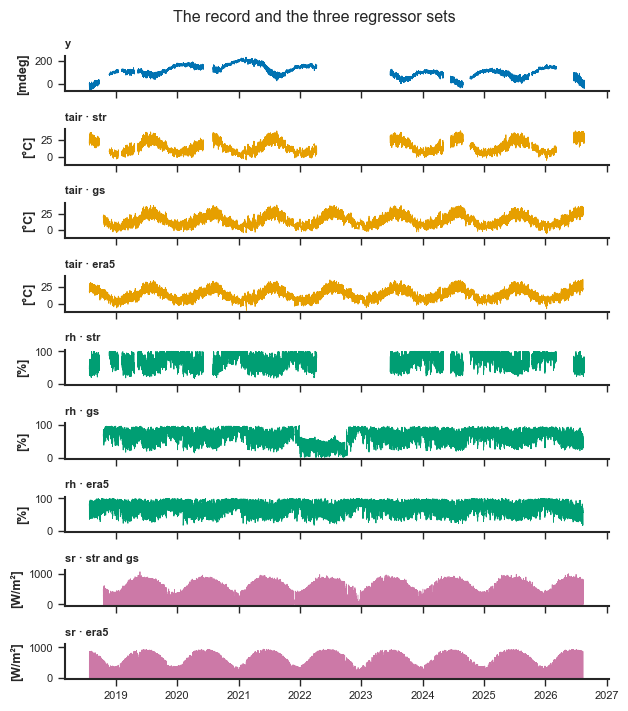

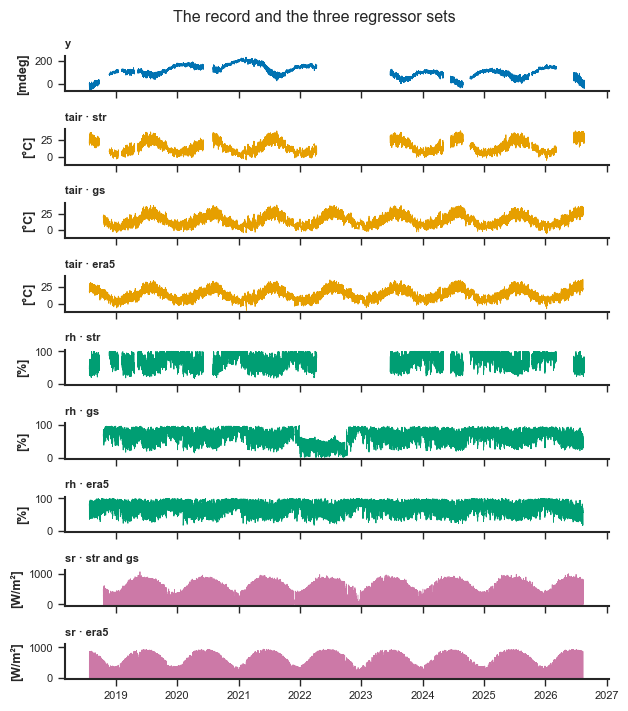

In [15]:
figures.plot_regressor_sets(
    frame, 'y', {n: {r: f'{r}_{n}' for r in ['tair', 'rh', 'sr']}
                 for n in sets},
    target_channel='inc_comp',
    title='The record and the three regressor sets',
    save_path=str(OUTPUT_DIR), filename='GM_F01_regressor_sets')

## Movement 1b · Harmonic diagnostics before modelling

Two series: the target, and the residual of a plain least-squares
regression of the target on the on-structure set's drivers. The spectral
scan fixes the seasonal orders; the daily cycle's amplitude and phase,
fitted against day of year, give the weight curve; the surface rank says
how many weighted daily shapes the conditional term needs (D6).

In [16]:
residual_ols, ols_gains = prediction.ols_residual(
    frame['y'], sets['str'][['tair', 'rh', 'sr']])
series_for_scan = {'target': frame['y'], 'residual': residual_ols}
print('OLS gains on the on-structure set:',
      ols_gains.drop('intercept').round(4).to_dict())

OLS gains on the on-structure set: {'tair': -4.3462, 'rh': -0.2271, 'sr': 0.0179}


,rank,period_days,period_years,power,resolution_days,n,span_days,series,band,block,order,holdout_mse,chosen,statistic,component,singular_value,variance_share,cumulative_share
0,1.0,1.000009,0.002738,0.011136,0.000339,143795.0,2947.916667,target,short,period_scan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,0.999556,0.002737,0.002345,0.000339,143795.0,2947.916667,target,short,period_scan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,1.000513,0.002739,0.002242,0.000340,143795.0,2947.916667,target,short,period_scan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,0.500006,0.001369,0.001395,0.000085,143795.0,2947.916667,target,short,period_scan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,1.001320,0.002741,0.000864,0.000340,143795.0,2947.916667,target,short,period_scan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,residual,NaN,surface_rank,NaN,NaN,NaN,NaN,48.0,0.360481,0.000007,0.999986
76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,residual,NaN,surface_rank,NaN,NaN,NaN,NaN,49.0,0.323372,0.000005,0.999991
77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,residual,NaN,surface_rank,NaN,NaN,NaN,NaN,50.0,0.293900,0.000004,0.999995
78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,residual,NaN,surface_rank,NaN,NaN,NaN,NaN,51.0,0.245864,0.000003,0.999998


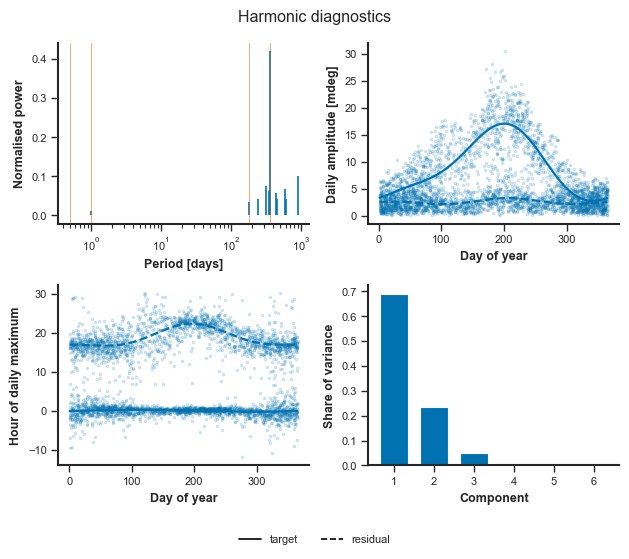

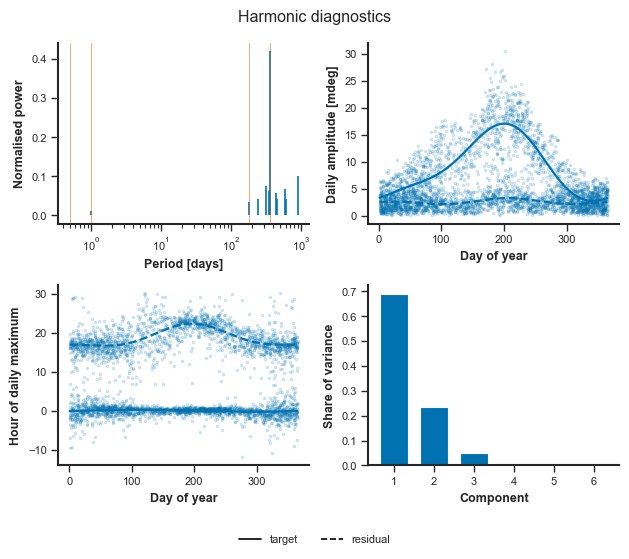

In [17]:
scans, dailies, fits = {}, {}, {}
for name, series in series_for_scan.items():
    scans[name] = pd.concat(
        [prediction.period_scan(series, min_days=lo, max_days=hi,
                                n_periods=PERIOD_SCAN_N, spacing='log', top=5)
         .assign(series=name, band=band_name)
         for band_name, (lo, hi) in PERIOD_SCAN_BANDS.items()],
        ignore_index=True)
    band = coupling.diurnal_band(series, window=72)
    dailies[name] = monitoring.daily_harmonic(band, min_slots=DAILY_HARMONIC_MIN_SLOTS)
    dailies[name]['phase_h'] = coupling.centre_phase(dailies[name]['phase_h'])
    table_a, fit_a = coupling.annual_modulation(dailies[name]['amplitude'],
                                                harmonics=ANNUAL_MODULATION_HARMONICS,
                                                min_gain=ANNUAL_MODULATION_MIN_GAIN)
    table_p, fit_p = coupling.annual_modulation(dailies[name]['phase_h'],
                                                harmonics=ANNUAL_MODULATION_HARMONICS,
                                                min_gain=ANNUAL_MODULATION_MIN_GAIN)
    fits[name] = {'amplitude': fit_a, 'phase': fit_p,
                  'amplitude_table': table_a.assign(series=name, statistic='amplitude'),
                  'phase_table': table_p.assign(series=name, statistic='phase')}
surface = coupling.cycle_surface_rank(coupling.diurnal_band(residual_ols, window=72),
                                      doy_bins=SURFACE_DOY_BINS, freq=NATIVE_FREQ)

scan_table = pd.concat(scans.values(), ignore_index=True).assign(block='period_scan')
modulation_table = pd.concat(
    [fits[n][k] for n in fits for k in ('amplitude_table', 'phase_table')],
    ignore_index=True).assign(block='annual_modulation')
harmonic = pd.concat(
    [scan_table, modulation_table,
     surface['table'].assign(block='surface_rank', series='residual')],
    ignore_index=True)
display(harmonic)
harmonic.to_csv(OUTPUT_DIR / 'GM_04_harmonic_diagnostics.csv', index=False)
tables.write_table(
    scan_table, str(OUTPUT_DIR / 'GM_04_body.tex'),
    [('series', tables.texttt), ('band', tables.texttt), ('rank', 'd'),
     ('period_days', ',.4f'), ('power', '.4f')])
tables.write_table(
    modulation_table, str(OUTPUT_DIR / 'GM_04b_body.tex'),
    [('series', tables.texttt), ('statistic', tables.texttt), ('order', 'd'),
     ('holdout_mse', ',.3f'), ('chosen', tables.yes_no)])
tables.write_table(
    surface['table'].head(6), str(OUTPUT_DIR / 'GM_04c_body.tex'),
    [('component', '.0f'), ('variance_share', tables.percent),
     ('cumulative_share', tables.percent)])

figures.plot_harmonic_diagnostics(
    scans, dailies, fits, surface, title='Harmonic diagnostics',
    save_path=str(OUTPUT_DIR), filename='GM_F02_harmonic_diagnostics')

In [18]:
# What the diagnostic decides, printed so the checkpoint can read it back.
short = scans['residual'][scans['residual']['band'] == 'short']
long_ = scans['residual'][scans['residual']['band'] == 'long']
has_semi_annual = prediction.has_certified_period(long_, 182.6)
has_annual = prediction.has_certified_period(long_, 365.25)
has_twelve_hour = prediction.has_certified_period(short, 0.5, tolerance_days=0.05)
has_daily = prediction.has_certified_period(short, 1.0, tolerance_days=0.05)
print('annual peak on the residual:', bool(has_annual))
print('semi-annual peak on the residual:', bool(has_semi_annual))
print('12-hour peak on the residual:', bool(has_twelve_hour))
print('daily peak on the residual:', bool(has_daily))
print('annual modulation order for the daily amplitude:', fits['residual']['amplitude']['order'])
print('first two surface components carry',
      f"{surface['table']['cumulative_share'].iloc[1]:.1%}")
weights_measured = prediction.seasonal_weights(frame.index, modulation=fits['residual']['amplitude'])
print('measured summer weight peaks on day', int(weights_measured['summer_w'].idxmax().dayofyear))
for name in fits:
    print(name, 'amplitude fit:',
          {k: (v.tolist() if hasattr(v, 'tolist') else v)
           for k, v in fits[name]['amplitude'].items()})
    print(name, 'certified periods:')
    display(scans[name])

annual peak on the residual: True
semi-annual peak on the residual: False
12-hour peak on the residual: True
daily peak on the residual: True
annual modulation order for the daily amplitude: 2
first two surface components carry 92.7%
measured summer weight peaks on day 206
target amplitude fit: {'order': 2, 'coef': [9.061563661783744, -6.582434888302295, -0.655121113281315, 0.8537902000658687, 1.434054170092692], 'period_days': 365.25, 'n': 1845}
target certified periods:


,rank,period_days,period_years,power,resolution_days,n,span_days,series,band
0,1,1.000009,0.002738,0.011136,0.000339,143795,2947.916667,target,short
1,2,0.999556,0.002737,0.002345,0.000339,143795,2947.916667,target,short
2,3,1.000513,0.002739,0.002242,0.000340,143795,2947.916667,target,short
3,4,0.500006,0.001369,0.001395,0.000085,143795,2947.916667,target,short
4,5,1.001320,0.002741,0.000864,0.000340,143795,2947.916667,target,short
5,1,364.181963,0.997076,0.419682,44.990587,143795,2947.916667,target,long
6,2,311.039268,0.851579,0.076119,32.818237,143795,2947.916667,target,long
7,3,436.864138,1.196069,0.056786,64.740729,143795,2947.916667,target,long
8,4,600.427653,1.643881,0.041925,122.294287,143795,2947.916667,target,long
9,5,181.682644,0.497420,0.034552,11.197258,143795,2947.916667,target,long


residual amplitude fit: {'order': 2, 'coef': [2.620081844364288, -0.29217943337223173, -0.13479289899282565, 0.2654898659335142, 0.26800490757467477], 'period_days': 365.25, 'n': 1752}
residual certified periods:


,rank,period_days,period_years,power,resolution_days,n,span_days,series,band
0,1,0.999909,0.002738,0.001236,0.000354,136574,2821.5,residual,short
1,2,1.000513,0.002739,0.001068,0.000355,136574,2821.5,residual,short
2,3,0.500006,0.001369,0.000657,0.000089,136574,2821.5,residual,short
3,4,0.499880,0.001369,0.000442,0.000089,136574,2821.5,residual,short
4,5,0.998952,0.002735,0.000414,0.000354,136574,2821.5,residual,short
5,1,900.000000,2.464066,0.099838,287.081340,136574,2821.5,residual,long
6,2,583.366881,1.597171,0.066593,120.615601,136574,2821.5,residual,long
7,3,352.692494,0.965619,0.061373,44.087186,136574,2821.5,residual,long
8,4,453.171694,1.240716,0.043285,72.785605,136574,2821.5,residual,long
9,5,244.099956,0.668309,0.041494,21.118125,136574,2821.5,residual,long
